In [10]:
import torch
from torch import nn
from d2l import torch as d2l


def dropout_layer(X, dropout):
    assert 0 <= dropout <= 1
    if dropout == 1:
        return torch.zeros_like(X)
    if dropout == 0:
        return X
    mask = (torch.rand(X.shape) > dropout).float()
    return mask * X / (1.0 - dropout)

**作用**：训练时随机让部分神经元 “失活”（输出置 0），缓解过拟合；测试时保留所有神经元。
- assert 确保 dropout 概率在 [0, 1] 范围内。
- 若 dropout=1，所有神经元失活，返回全 0 张量；若 dropout=0，无神经元失活，返回原张量。
- 生成随机掩码 mask：用 torch.rand 生成与 X 同形状的 0~1 随机数，大于 dropout 的位置为 1（保留神经元），否则为 0（失活神经元）。
- 对保留的神经元输出做缩放补偿：mask * X / (1.0 - dropout)，保证神经元输出的期望与无 Dropout 时一致（避免训练 / 测试阶段输出分布差异）。

In [11]:
X= torch.arange(16, dtype = torch.float32).reshape((2, 8))
print(X)
print(dropout_layer(X, 0.))
print(dropout_layer(X, 0.5))
print(dropout_layer(X, 1.))

tensor([[ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11., 12., 13., 14., 15.]])
tensor([[ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11., 12., 13., 14., 15.]])
tensor([[ 0.,  2.,  0.,  0.,  8.,  0.,  0.,  0.],
        [ 0., 18.,  0., 22., 24.,  0., 28.,  0.]])
tensor([[0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.]])


In [12]:
num_inputs, num_outputs, num_hiddens1, num_hiddens2 = 784, 10, 256, 256

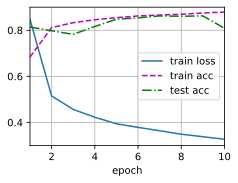

In [16]:
dropout1, dropout2 = 0.2, 0.5

class Net(nn.Module):
    def __init__(self, num_inputs, num_outputs, num_hiddens1, num_hiddens2):
        super(Net, self).__init__()
        self.num_inputs = num_inputs
        self.lin1 = nn.Linear(num_inputs, num_hiddens1)
        self.lin2 = nn.Linear(num_hiddens1, num_hiddens2)
        self.lin3 = nn.Linear(num_hiddens2, num_outputs)
        self.relu = nn.ReLU()

    def forward(self, X):
        H1 = self.relu(self.lin1(X.reshape((-1, self.num_inputs))))
        if self.training:
            H1 = dropout_layer(H1, dropout1)
        H2 = self.relu(self.lin2(H1))
        if self.training:
            H2 = dropout_layer(H2, dropout2)
        out = self.lin3(H2)
        return out

net = Net(num_inputs, num_outputs, num_hiddens1, num_hiddens2)

num_epochs, lr, batch_size = 10, 0.5, 256
loss = nn.CrossEntropyLoss()  # 修复为标量输出
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)
trainer = torch.optim.SGD(net.parameters(), lr=lr)
d2l.train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)

**网络结构**：3 层全连接网络（<u>输入层→隐藏层 1→隐藏层 2→输出层</u>），激活函数用 ReLU。

### Dropout 策略：

- 仅在训练阶段（self.training=True，由 model.train() 触发）对隐藏层输出应用 Dropout；测试阶段（model.eval()）不应用 Dropout，保留所有神经元。
- 隐藏层 1 失活概率 dropout1=0.2（20% 神经元失活），隐藏层 2 失活概率 dropout2=0.5（50% 神经元失活）。

### 关键参数：
num_inputs=784（FashionMNIST 图片为 28×28 像素，展平后为 784 维输入），num_outputs=10（10 分类任务），隐藏层维度 256。
训练轮数 10，学习率 0.5，批量大小 256。
训练逻辑：d2l.train_ch3 会自动处理训练 / 测试阶段的切换（训练时 net.train()，测试时 net.eval()），并输出准确率曲线（如图中折线图，用于观察过拟合缓解效果）。

### 核心思想：Dropout 为什么能缓解过拟合？
Dropout 通过随机失活神经元，打破了神经元间的 “共适应”（某些神经元过度依赖其他神经元的特定组合），迫使网络学习更鲁棒的特征。测试时无 Dropout，所有神经元参与计算，保证预测稳定性。

In [17]:
net = nn.Sequential(nn.Flatten(),
        nn.Linear(784, 256),
        nn.ReLU(),
        # 在第一个全连接层之后添加一个dropout层
        nn.Dropout(dropout1),
        nn.Linear(256, 256),
        nn.ReLU(),
        # 在第二个全连接层之后添加一个dropout层
        nn.Dropout(dropout2),
        nn.Linear(256, 10))

def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.01)

net.apply(init_weights);

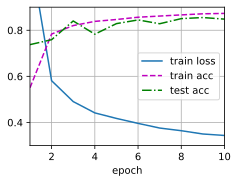

In [18]:
trainer = torch.optim.SGD(net.parameters(), lr=lr)
d2l.train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)

1. 网络结构解读
这段代码用 PyTorch 构建了一个带 Dropout 的全连接神经网络，用于 MNIST 手写数字识别：
- 输入层：nn.Flatten() 将 28×28 的图像展平为 784 维向量。
- 隐藏层：
   - 两层全连接层（Linear(784,256) → Linear(256,256)），搭配 ReLU 激活函数。
   - 每层全连接后加入 Dropout，随机失活部分神经元以抑制过拟合。
- 输出层：Linear(256,10) 输出 10 类概率（对应 0-9 数字）。
- 权重初始化：对全连接层权重做正态初始化（std=0.01），避免初始权重过大导致训练不稳定。
2. 训练曲线分析
- 从下方的 loss/acc 曲线可以看出：
   - 训练损失（train loss）：随 epoch 增加持续下降，说明模型在有效拟合训练数据。
   - 训练准确率（train acc）：稳步上升，后期接近 0.9，表明模型对训练集的识别能力在提升。
   - 测试准确率（test acc）：与训练准确率趋势同步上升，无明显过拟合（若过拟合，测试准确率会后期下降），说明 Dropout 有效提升了模型泛化能力。

# 暂退法（Dropout）总结

## 一、核心定位与解决问题

1. **本质**：深度学习中常用的**正则化技术**，通过训练时随机丢弃部分神经元，抑制模型过拟合，提升泛化能力。

2. **针对痛点**：深度神经网络灵活性强（可学习特征交互），即使样本量充足也可能过拟合（如随机标记图像仍能完美拟合训练集，泛化差距达90%）；核心原因是神经元间形成“共适应性”（过度依赖少数神经元的关联）。

3. **与其他正则化的关联**：补充权重衰减（L2正则化），从“破坏共适应性”角度解决过拟合，而非仅惩罚权重范数。

## 二、核心原理

### 1. 核心思想：无偏扰动增强平滑性

- 灵感来源：毕晓普1995年研究（输入噪声训练等价于Tikhonov正则化），将“输入加噪”扩展到**网络内部层**——训练时对中间层激活值注入噪声，强制模型对输入/神经元微小变化不敏感（平滑性）。

- 无偏性保证：扰动后神经元激活值的期望值与原始值一致，避免引入额外偏差。

### 2. 数学定义

设原始神经元激活值为  $h$ ，暂退概率为  $p$ （神经元被丢弃的概率），扰动后激活值  $h'$  满足：


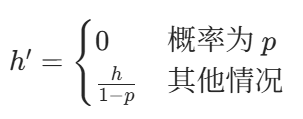


- 丢弃：以概率  $p$  将神经元置零，切断其与前后层的连接；

- 规范化：保留的神经元激活值除以  $1-p$ ，确保  $\mathbb{E}[h'] = h$ （无偏）。

## 三、实践关键细节

### 1. 训练与测试的差异

- **训练时**：启用暂退，随机丢弃神经元，对保留值规范化；

- **测试时**：禁用暂退，不丢弃任何神经元，无需规范化（直接使用全部神经元的输出）；

- 例外场景：测试时可启用暂退，通过多次扰动的预测一致性估计模型“不确定性”。

### 2. 暂退概率设置技巧

- 暂退概率  $p \in [0,1]$ ： $p=0$  无暂退（全保留）， $p=1$  全丢弃（仅理论场景）；

- 层间差异：靠近输入层的暂退概率通常设得更低（如0.2），避免过度破坏原始特征；深层可适当提高（如0.5）。

## 四、实现方式（PyTorch）

### 1. 从零开始实现

- 核心函数 `dropout_layer`：生成与输入维度一致的随机掩码（均匀分布  $U[0,1]$ ），保留掩码值大于  $p$  的元素，规范化后返回；

- 模型设计：仅在训练模式下启用暂退，隐藏层激活后执行暂退操作。

### 2. 简洁实现（框架API）

- 直接使用 `nn.Dropout(p)` 层，插入全连接层与激活函数之间；

- 框架自动处理训练/测试模式切换（无需手动判断 `is_training`）；

- 配合权重初始化（如正态分布 `std=0.01`），提升训练稳定性。

## 五、核心结论

1. 暂退法通过“随机丢弃神经元”破坏共适应性，强制模型学习更鲁棒的特征；

2. 核心保障是“无偏扰动”，确保训练与测试的输出期望一致；

3. 仅在训练时生效，测试时需关闭，常与权重衰减、合适的初始化配合使用；

4. 适用于深度神经网络，尤其在处理高维特征（如图像）、样本有限时，抑制过拟合效果显著。